# Data

[data](https://www.kaggle.com/datasets/somesh24/spambase)

- SPAM E-mail Database
    - The “spam” concept is diverse: advertisements for products/websites, make money fast schemes, chain letters, pornography… Our collection of spam e-mails came from our postmaster and individuals who had filed spam. Our collection of non-spam e-mails came from filed work and personal e-mails, and hence the word ‘george’ and the area code ‘650’ are indicators of non-spam. These are useful when constructing a personalized spam filter. One would either have to blind such non-spam indicators or get a very wide collection of non-spam to generate a general purpose spam filter.
- Attribute Information:
    - The last column denotes wåhether the e-mail was considered spam (1) or not (0), i.e. unsolicited commercial e-mail. Most of the attributes indicate whether a particular word or character was frequently occurring in the e-mail. The run-length attributes (55-57) measure the length of sequences of consecutive capital letters.
    - For the statistical measures of each attribute, see the end of this file. Here are the definitions of the attributes:
    - 48 continuous real [0,100] attributes of type word_freq_WORD = percentage of words in the e-mail that match WORD, i.e. 100 * (number of times the WORD appears in the e-mail) / total number of words in e-mail. A “word” in this case is any string of alphanumeric characters bounded by non-alphanumeric characters or end-of-string.
    - 6 continuous real [0,100] attributes of type char_freq_CHAR = percentage of characters in the e-mail that match CHAR, i.e. 100 * (number of CHAR occurrences) / total characters in e-mail
    - 1 continuous real [1,…] attribute of type capital_run_length_average = average length of uninterrupted sequences of capital letters
    - 1 continuous integer [1,…] attribute of type capital_run_length_longest = length of longest uninterrupted sequence of capital letters
    - 1 continuous integer [1,…] attribute of type capital_run_length_total = sum of length of uninterrupted sequences of capital letters = total number of capital letters in the e-mail
    - 1 nominal {0,1} class attribute of type spam = denotes whether the e-mail was considered spam (1) or not (0), i.e. unsolicited commercial e-mail.

# Import

In [232]:
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

In [2]:
df = pd.read_csv('../../../delete/spambase_csv.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [105]:
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


# EDA

- spam vs not spam

Text(0.5, 1.0, 'Distribution of Spam Emails')

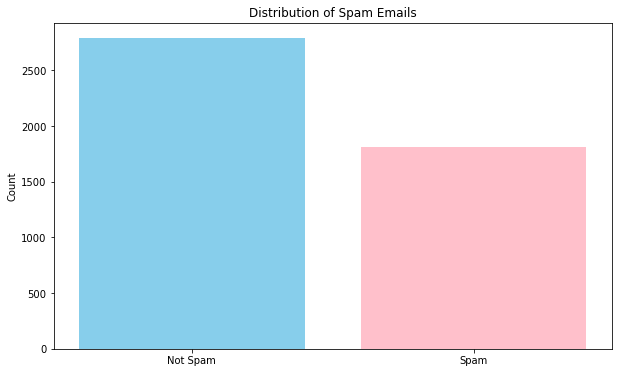

In [37]:
plt.figure(figsize=(10,6))
plt.bar(df['class'].value_counts().sort_index().index,df['class'].value_counts().sort_index().values, color=['skyblue','pink'])
plt.xticks([0,1],['Not Spam','Spam'],fontsize=10)
plt.ylabel('Count')
plt.title('Distribution of Spam Emails')

- Top 15

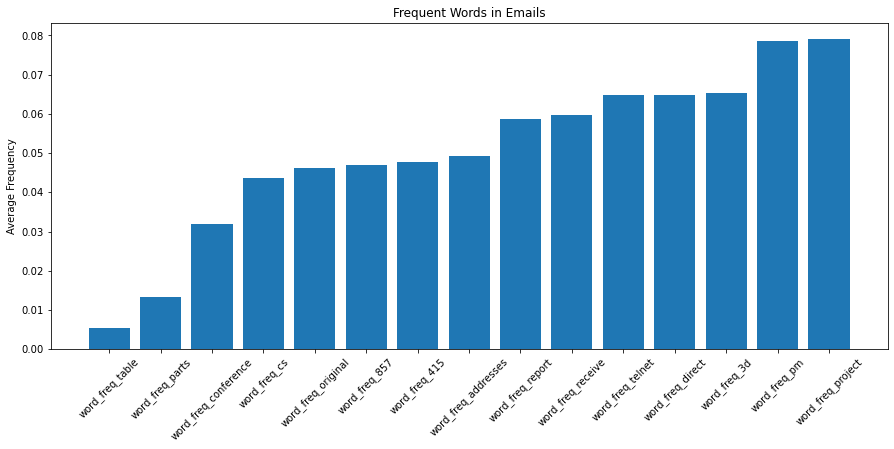

In [87]:
plt.figure(figsize=(15,6))
plt.bar(df[[col for col in df.columns if col.startswith("word_freq")]].mean().sort_values().head(15).index,\
       df[[col for col in df.columns if col.startswith("word_freq")]].mean().sort_values().head(15).values)
plt.title('Frequent Words in Emails')
plt.ylabel('Average Frequency')
plt.xticks(rotation=45);

- Heatmap

<Axes: >

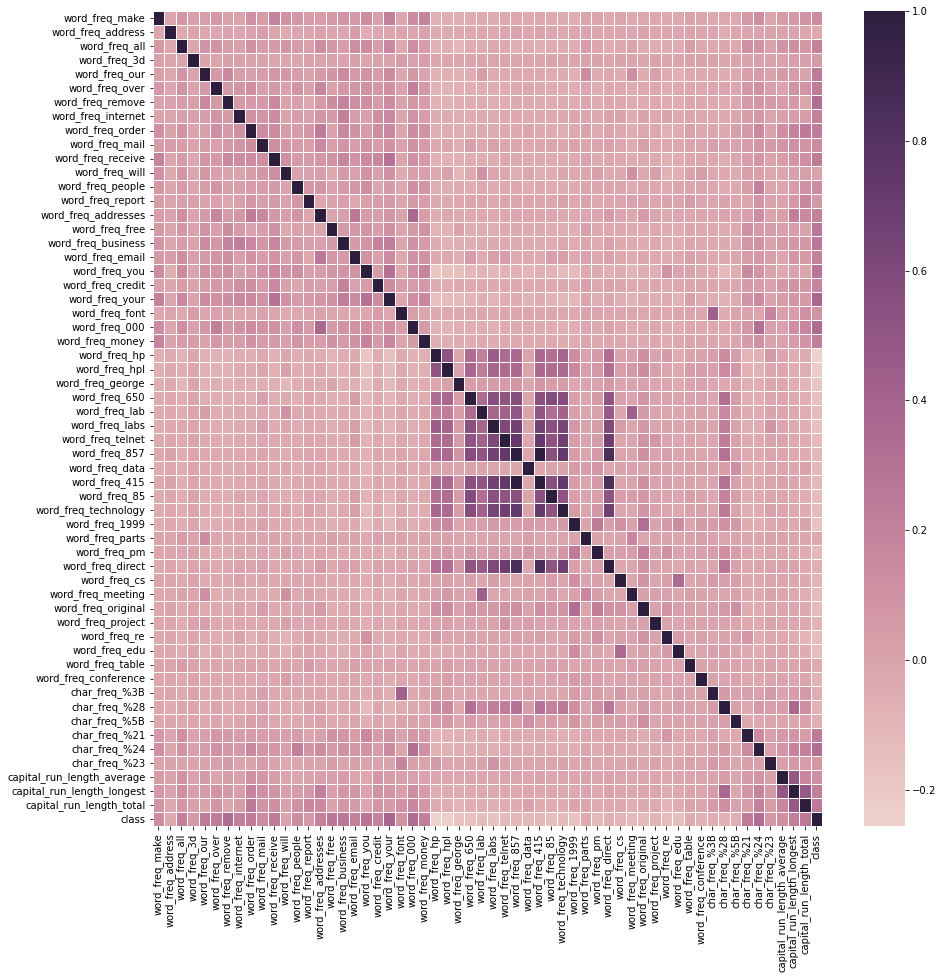

In [116]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(),annot=False, linewidth=.5, cmap=sns.cubehelix_palette(as_cmap=True))

- Capital Length

In [141]:
print('Not Spam :',round(df[df['class']==0]['capital_run_length_total'].mean(),4))

Not Spam : 161.4709


In [145]:
print('Not Spam (Max) :',round(df[df['class']==0]['capital_run_length_total'].max(),4))

Not Spam (Max) : 5902


In [142]:
print('Spam :',round(df[df['class']==1]['capital_run_length_total'].mean(),4))

Spam : 470.6194


In [146]:
print('Spam (Max) :',round(df[df['class']==1]['capital_run_length_total'].max(),4))

Spam (Max) : 15841


([<matplotlib.axis.XTick at 0x7fc0b7a85640>,
 [Text(0, 0, 'Not Spam'), Text(1, 0, 'Spam')])

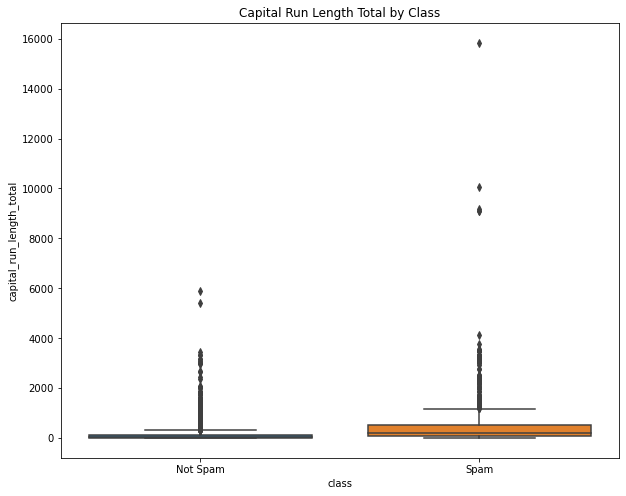

In [122]:
plt.figure(figsize=(10,8))
sns.boxplot(x='class', y='capital_run_length_total', data=df)
plt.title("Capital Run Length Total by Class")
plt.xticks([0,1],['Not Spam','Spam'],fontsize=10)

- frequent words

In [166]:
df[df['class']==1][[col for col in df.columns if col.startswith("word_freq")]].mean().sort_values(ascending=False).head(20)

word_freq_you         2.264539
word_freq_your        1.380370
word_freq_will        0.549972
word_freq_free        0.518362
word_freq_our         0.513955
word_freq_all         0.403795
word_freq_mail        0.350507
word_freq_email       0.319228
word_freq_business    0.287507
word_freq_remove      0.275405
word_freq_000         0.247055
word_freq_font        0.238036
word_freq_money       0.212879
word_freq_internet    0.208141
word_freq_credit      0.205521
word_freq_over        0.174876
word_freq_order       0.170061
word_freq_3d          0.164672
word_freq_address     0.164650
word_freq_make        0.152339
dtype: float64

In [165]:
df[df['class']==0][[col for col in df.columns if col.startswith("word_freq")]].mean().sort_values(ascending=False).head(10)

word_freq_you        1.270341
word_freq_george     1.265265
word_freq_hp         0.895473
word_freq_will       0.536324
word_freq_your       0.438702
word_freq_hpl        0.431994
word_freq_re         0.415760
word_freq_edu        0.287184
word_freq_address    0.244466
word_freq_meeting    0.216808
dtype: float64

([<matplotlib.axis.XTick at 0x7fc0b73c0b80>,
 [Text(0, 0, 'Not Spam'), Text(1, 0, 'Spam')])

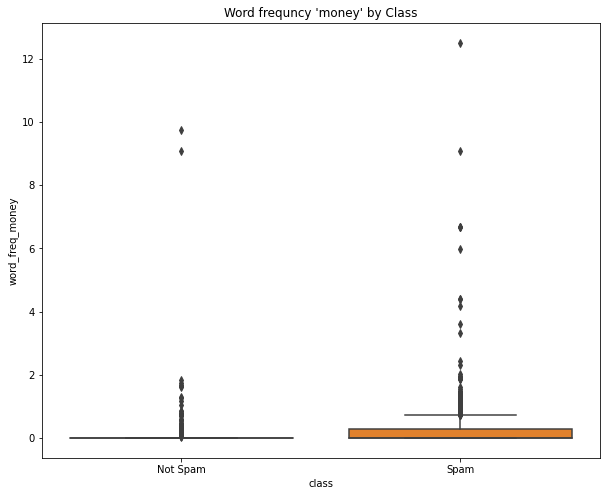

In [169]:
plt.figure(figsize=(10,8))
sns.boxplot(x='class', y='word_freq_money', data=df)
plt.title("Word frequncy 'money' by Class")
plt.xticks([0,1],['Not Spam','Spam'],fontsize=10)

([<matplotlib.axis.XTick at 0x7fc0b729c850>,
 [Text(0, 0, 'Not Spam'), Text(1, 0, 'Spam')])

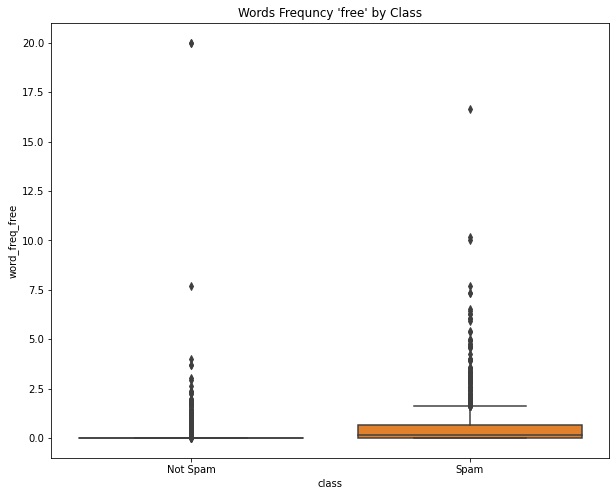

In [170]:
plt.figure(figsize=(10,8))
sns.boxplot(x='class', y='word_freq_free', data=df)
plt.title("Words Frequncy 'free' by Class")
plt.xticks([0,1],['Not Spam','Spam'],fontsize=10)

# PCA

In [190]:
X = df.drop('class', axis =1)
y = df['class']

In [191]:
X_scaled = StandardScaler().fit_transform(X)

In [192]:
pca = PCA(n_components=2)

In [193]:
components=pca.fit_transform(X_scaled)

In [194]:
components

array([[-0.73174728, -0.04293728],
       [-1.18508882,  2.06825469],
       [-1.46759045,  5.02266333],
       ...,
       [-0.26187932, -0.41736537],
       [-0.58982762, -0.66145043],
       [-0.73881084, -0.64724354]])

- most likely divided classes

Text(0, 0.5, 'PC2')

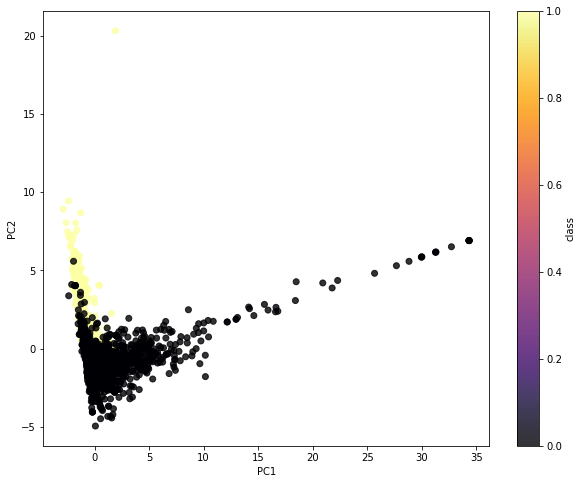

In [195]:
plt.figure(figsize=(10,8))
plt.scatter(components[:,0],components[:,1],c=y, cmap='inferno',alpha=0.8)
plt.colorbar(label='class')
plt.xlabel('PC1')
plt.ylabel('PC2')

- PC1 explains well feature of 'Not Spam' mails.
- PC2 explains well feature of 'Spam' mails.


# Logistic Regression

In [190]:
X = df.drop('class', axis =1)
y = df['class']

In [199]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=1212)

In [200]:
scaler = StandardScaler()

In [201]:
X_train_scaled = scaler.fit_transform(X_train)

In [202]:
X_test_scaled = scaler.fit_transform(X_test)

In [203]:
logit = LogisticRegression(max_iter=150)

In [204]:
logit.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=150)

In [205]:
y_pred = logit.predict(X_test_scaled)

In [209]:
y_pred_proba = logit.predict_proba(X_test_scaled)[:,1]

In [227]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[802,  58],
       [ 47, 474]])

In [213]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.93      0.94       860
           1       0.89      0.91      0.90       521

    accuracy                           0.92      1381
   macro avg       0.92      0.92      0.92      1381
weighted avg       0.92      0.92      0.92      1381



In [229]:
dis = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=logit.classes_)

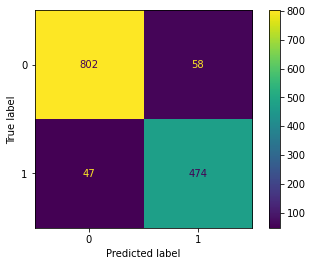

In [231]:
dis.plot()

- AUC

In [215]:
round(roc_auc_score(y_test,y_pred_proba),4)

0.9688

- ROC Curve

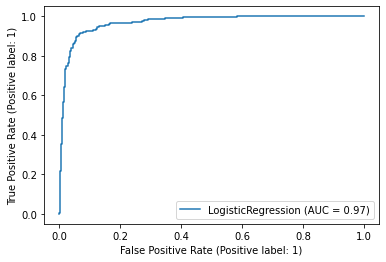

In [233]:
RocCurveDisplay.from_estimator(logit, X_test_scaled, y_test)

- high probability of features top10

In [225]:
pd.DataFrame({'feature':X.columns,'coef':logit.coef_[0]}).sort_values(by='coef',ascending=False).head(10)

,feature,coef
23,word_freq_money,1.168081
53,char_freq_%23,1.013748
22,word_freq_000,0.907612
52,char_freq_%24,0.877258
6,word_freq_remove,0.755996
15,word_freq_free,0.740973
55,capital_run_length_longest,0.517987
3,word_freq_3d,0.510681
19,word_freq_credit,0.510549
56,capital_run_length_total,0.488242
